In [5]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib as mpl
from scipy.stats import pearsonr, spearmanr

1. 꿀벌군집 데이터를 GeoDataFrame으로 변환

In [6]:
bee_df = pd.read_csv('../../data/raw/SBV_Infection_Location.csv', encoding='cp949')  # 인코딩 오류 대비 cp949
bee_df = bee_df.dropna(subset=['Longitude', 'Latitude', '발생두수'])

gdf_bee = gpd.GeoDataFrame(
    bee_df,
    geometry=gpd.points_from_xy(bee_df['Longitude'], bee_df['Latitude']),
    crs="EPSG:4326"
)

2. 도 경계와 spatial join

In [7]:
korea_map = gpd.read_file('../../data/raw/map.shp', encoding='euc-kr')
if korea_map.crs is None:
    korea_map.set_crs("EPSG:5179", inplace=True)
korea_map = korea_map.to_crs("EPSG:4326")

bee_with_region = gpd.sjoin(gdf_bee, korea_map[['CTP_KOR_NM', 'geometry']], how='left', predicate='within')

3. 도별 평균기온 매핑

In [8]:
bee_with_temp = bee_with_region.merge(summer_temp[['CTP_KOR_NM', '평균기온(°C)']], on='CTP_KOR_NM', how='left')


4. 상관 분석

In [9]:
from scipy.stats import pearsonr, spearmanr

df = bee_with_temp.dropna(subset=['발생두수', '평균기온(°C)'])
pearson_r, pearson_p = pearsonr(df['평균기온(°C)'], df['발생두수'])
spearman_r, spearman_p = spearmanr(df['평균기온(°C)'], df['발생두수'])

print(f"[Pearson] 평균기온 vs 발생두수: r = {pearson_r:.4f}, p = {pearson_p:.4f}")
print(f"[Spearman] 평균기온 vs 발생두수: ρ = {spearman_r:.4f}, p = {spearman_p:.4f}")

[Pearson] 평균기온 vs 발생두수: r = 0.0579, p = 0.0324
[Spearman] 평균기온 vs 발생두수: ρ = 0.0105, p = 0.6990


                            OLS Regression Results                            
Dep. Variable:                   발생두수   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.587
Date:                Wed, 25 Jun 2025   Prob (F-statistic):             0.0324
Time:                        14:02:42   Log-Likelihood:                -7167.9
No. Observations:                1368   AIC:                         1.434e+04
Df Residuals:                    1366   BIC:                         1.435e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -65.2410     39.162     -1.666      0.0

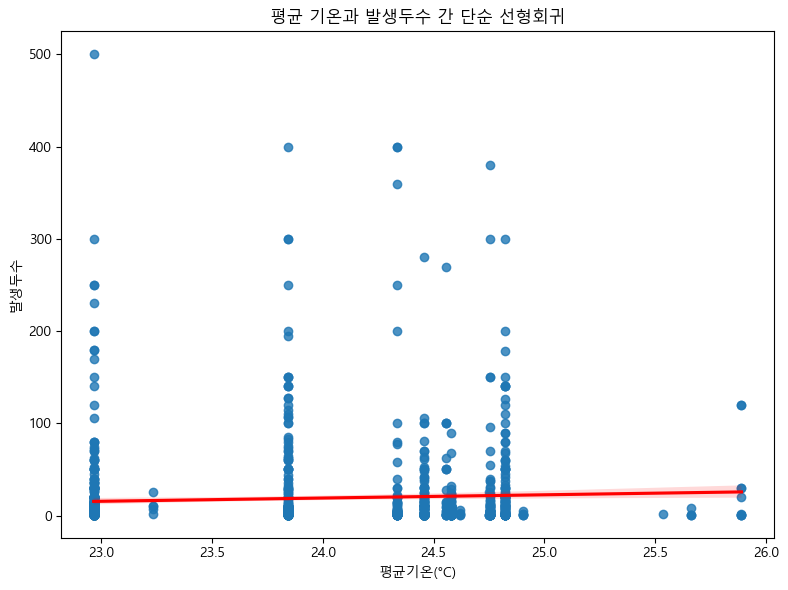

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.font_manager as fm
import matplotlib as mpl

# 한글 폰트 설정
font_path = 'C:/Windows/Fonts/malgun.ttf'
fontprop = fm.FontProperties(fname=font_path)
mpl.rc('font', family=fontprop.get_name())
mpl.rcParams['axes.unicode_minus'] = False

weather = pd.read_csv("../../data/raw/weather.csv", encoding='euc-kr')
weather_location = pd.read_csv("../../data/raw/weather_station_info.csv", encoding='euc-kr')

weather[['year', 'month']] = weather['일시'].str.split('-', expand=True)
weather['year'] = weather['year'].astype(int)
weather['month'] = weather['month'].astype(int)

def season_month(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'

weather['season'] = weather['month'].apply(season_month)

avg_by_month = weather.groupby(['지점', 'season'])[weather.columns[3:15]].mean().reset_index()

weather_location = weather_location[['지점', '위도', '경도']]
weather = weather.merge(weather_location, on='지점', how='left')

gdf_points = gpd.GeoDataFrame(
    weather,
    geometry=gpd.points_from_xy(weather['경도'], weather['위도']),
    crs="EPSG:4326"
)

korea_map = gpd.read_file('../../data/raw/map.shp', encoding='euc-kr')
if korea_map.crs is None:
    korea_map.set_crs("EPSG:5179", inplace=True)
korea_map = korea_map.to_crs("EPSG:4326")

joined = gpd.sjoin(gdf_points, korea_map[['CTP_KOR_NM', 'geometry']], how='left', predicate='within')

avg_temp = joined.groupby(['CTP_KOR_NM', 'season'])['평균기온(°C)'].mean().reset_index()
summer_temp = avg_temp[avg_temp['season'] == 'summer']

bee_data = pd.read_csv("../../data/raw/SBV_Infection_Location.csv", encoding='euc-kr')
bee_data = bee_data[['Longitude', 'Latitude', '발생두수', '축종']].dropna()

bee_gdf = gpd.GeoDataFrame(
    bee_data,
    geometry=gpd.points_from_xy(bee_data['Longitude'], bee_data['Latitude']),
    crs="EPSG:4326"
)
bee_gdf = gpd.sjoin(bee_gdf, korea_map[['CTP_KOR_NM', 'geometry']], how='left', predicate='within')

bee_gdf = bee_gdf.merge(summer_temp[['CTP_KOR_NM', '평균기온(°C)']], on='CTP_KOR_NM', how='left')
df = bee_gdf.dropna(subset=['발생두수', '평균기온(°C)'])

# 단순 선형회귀
X = sm.add_constant(df[['평균기온(°C)']])
y = df['발생두수']
model = sm.OLS(y, X).fit()

print(model.summary())

plt.figure(figsize=(8, 6))
sns.regplot(x='평균기온(°C)', y='발생두수', data=df, ci=95, line_kws={"color": "red"})
plt.title("평균 기온과 발생두수 간 단순 선형회귀")
plt.xlabel("평균기온(°C)")
plt.ylabel("발생두수")
plt.tight_layout()
plt.savefig("../../outputs/figures/2_1_3_regression_temp_vs_infection.png", dpi=300)
plt.show()


                            OLS Regression Results                            
Dep. Variable:               log_발생두수   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.511
Date:                Wed, 25 Jun 2025   Prob (F-statistic):              0.113
Time:                        14:06:40   Log-Likelihood:                -2222.0
No. Observations:                1368   AIC:                             4448.
Df Residuals:                    1366   BIC:                             4459.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2756      1.054      0.262      0.7

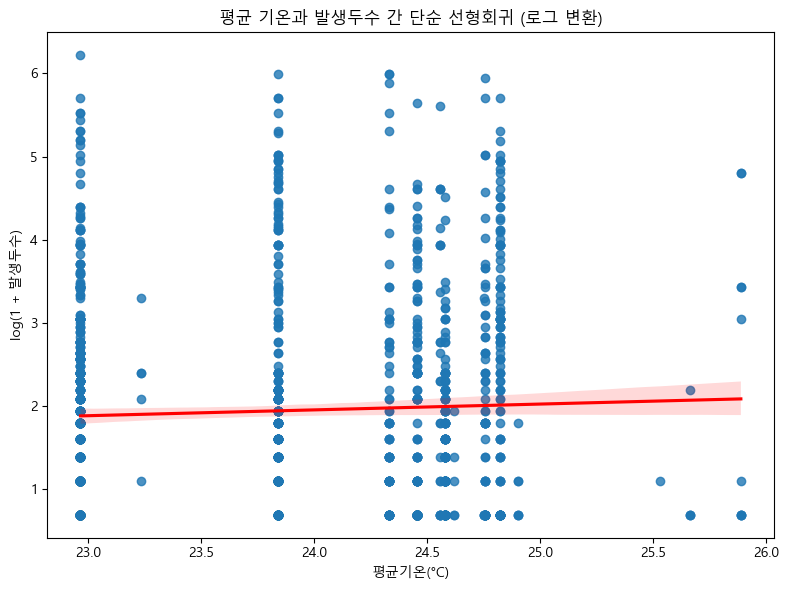

In [ ]:
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# 로그 변환
df['log_발생두수'] = np.log1p(df['발생두수'])

X = sm.add_constant(df[['평균기온(°C)']])
y = df['log_발생두수']
model = sm.OLS(y, X).fit()

print(model.summary())

plt.figure(figsize=(8, 6))
sns.regplot(x='평균기온(°C)', y='log_발생두수', data=df, ci=95, line_kws={"color": "red"})
plt.title("평균 기온과 발생두수 간 단순 선형회귀 (로그 변환)")
plt.xlabel("평균기온(°C)")
plt.ylabel("log(1 + 발생두수)")
plt.tight_layout()
plt.savefig("../../outputs/figures/2_1_4_regression_temp_vs_log_infection.png", dpi=300)
plt.show()
